In [1]:
# MPI

import os
import sys

# Add the '../sources' directory to the Python path using source_dir,
# and add its parent directory as well.
source_dir = os.path.abspath(os.path.join("..", "sources"))
parent_dir = os.path.abspath(os.path.join(source_dir, os.pardir))

for directory in [source_dir, parent_dir]:
    if directory not in sys.path:
        sys.path.insert(0, directory)


In [2]:

print(f"Included '{source_dir}' and its parent directory '{parent_dir}' in sys.path.")
## Define the materials
from sources.photonic_crystal_maker import Material
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal, ScriptParam, ScriptParamVector3
from sources.mpb_configurator import MPBSchemeConfigurator  
import meep as mp
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from sources.mpb_configurator import *




eps_Si = round(12,2)
eps_InP = round(3.1**2,2)
print("Epsilon of InP: ", eps_InP)
Si = Material(epsilon = eps_Si)
InP = Material(epsilon = eps_InP)
AIR = Material(epsilon = 1)
## Simulation Name: 
name = "test_simple_lattices"






## Define the geometry
radius1 = ScriptParam("r1", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice
lattice_2D = Lattice(type="TX")
lattice_slab = Lattice(type="TX", size=mp.Vector3(1, 1, height_supercell))
centers = lattice_2D.get_centers()
k_points = lattice_2D.get_high_symmetry_k_points()

BULK = InP
ATOM = AIR

bulk_2D = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": mp.Vector3(1e20, 1e20, 1e20), "material": BULK})
bulk_slab = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": slab_block_size, "material": BULK})
hole1_2D = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": 1e20, "material": ATOM})
hole1_slab = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": height_slab, "material": ATOM})

photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=[bulk_2D, hole1_2D])
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=[bulk_slab, hole1_slab])

## Define the simulation


configuration_options = dict(
    resolution = 32, 
    num_bands=8,
    k_points=k_points["k_points_values"],
    k_point_interpolation_factor=4, 
    extra_runner_command = "fix-efield-phase output-efield-z",
)

mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven", "zodd"], **configuration_options)
script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)

Included '/zhome/2f/7/202918/phc_nzi/sources' and its parent directory '/zhome/2f/7/202918/phc_nzi' in sys.path.
Epsilon of InP:  9.61
Found script param: size with value: (vector3 1e+20 1e+20 h)
Found script param: radius with value: r1
Found script param: radius with value: r1
Found script param: height with value: h
COMMANDS ['(define-param r1 0.2)']
COMMANDS ['(define-param h 0.4)', '(define-param r1 0.2)']


In [3]:
print(script_2D)    

(set! num-bands 8)
(set! resolution 32)
(set! k-points (list (vector3 0.0 0.0 0.0) (vector3 0.0 0.5 0.0) (vector3 -0.3333333333333333 0.3333333333333333 0.0) (vector3 0.0 0.0 0.0)))
(set! k-points (interpolate 4 k-points))
(define-param r1 0.2)
(set! geometry-lattice (make lattice (size 1 1 no-size)  (basis1  (vector3 1.0 0.0 0.0)) (basis2  (vector3 0.5000000000000001 0.8660254037844388 0.0)) ))
(set! geometry (list 
 (make block (center (vector3 0.0 0.0 0.0))
  (size (vector3 1e+20 1e+20 1e+20))
  (material (make dielectric (epsilon 9.61))))
 (make cylinder (center 0.0)
  (radius r1)
  (height 1e+20)
  (material (make dielectric (epsilon 1))))
))
(run-te fix-efield-phase output-efield-z)
(run-tm fix-efield-phase output-efield-z)


In [4]:

from sources.mpi_differential_evolution import MPIDiffEvoSimulation
from sources.simulation_handler import Simulation
from sources.simulation_handler import SimulationViewer

# Create your Simulation instance.
simulation_2D = Simulation(simulation_name=name+"_2D",
                 script=script_2D,
                 log_level = Simulation.WARNING)

simulation_slab = Simulation(simulation_name=name+"_slab",
                    script=script_slab,
                    log_level = Simulation.WARNING)

    


In [5]:
#simulation_2D.run_hpc(mpb_command_line_params={"r1":0.20})


,k index,k1,k2,k3,kmag/2pi,tm band 1,tm band 2,tm band 3,tm band 4,tm band 5,tm band 6,tm band 7,tm band 8
0,1,0.000000,0.000000,0,0.000000,0.000000,0.372715,0.374821,0.374823,0.396486,0.396638,0.487346,0.651218
1,2,0.000000,0.100000,0,0.115470,0.039917,0.343730,0.365253,0.383796,0.408964,0.409660,0.496454,0.627078
2,3,0.000000,0.200000,0,0.230940,0.079723,0.310083,0.352306,0.374707,0.430316,0.436942,0.518329,0.597078
3,4,0.000000,0.300000,0,0.346410,0.119266,0.274394,0.342172,0.365193,0.454457,0.465124,0.544050,0.567126
4,5,0.000000,0.400000,0,0.461880,0.158167,0.237596,0.335840,0.358786,0.480236,0.493078,0.537962,0.550868
5,6,0.000000,0.500000,0,0.577350,0.189067,0.207363,0.333691,0.356561,0.502071,0.513204,0.515014,0.534413
6,7,-0.066667,0.466667,0,0.581187,0.190321,0.208564,0.320615,0.369609,0.493344,0.509525,0.522162,0.539713
7,8,-0.133333,0.433333,0,0.592546,0.194033,0.212016,0.300453,0.389749,0.481073,0.499500,0.535088,0.549211
8,9,-0.200000,0.400000,0,0.611010,0.200065,0.217113,0.280094,0.410381,0.468926,0.488946,0.548195,0.559055
9,10,-0.266667,0.366667,0,0.635959,0.208213,0.221747,0.262061,0.430283,0.457258,0.479262,0.560896,0.568405


{2: 0.372715, 3: 0.374821, 4: 0.374823}


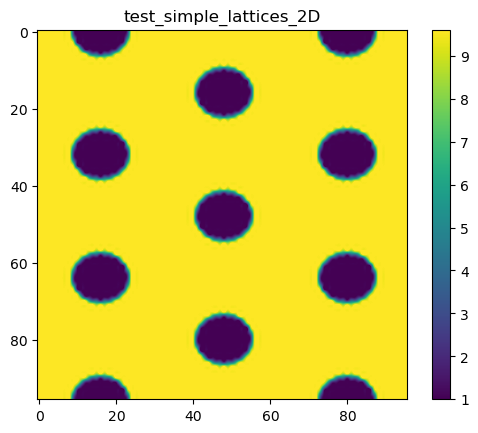

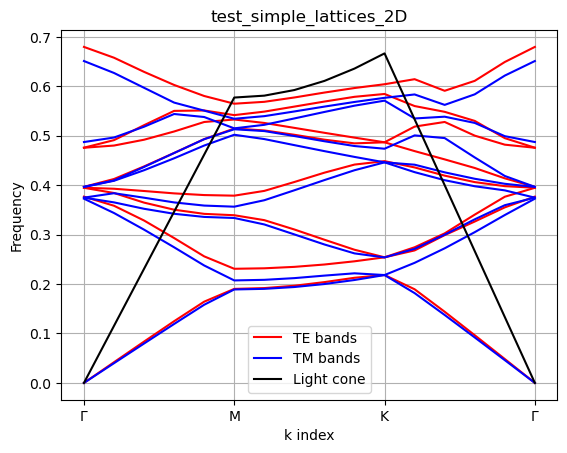

In [6]:

sim = simulation_2D
df =sim.load_frequency_data("tm")
display(df)
freqs = sim.get_frequencies_by_band(df, "tm")
print(freqs)
cost = abs(freqs[4] - freqs[2])

conversion_options = dict(
    periods = 5,
    rectify = True, 
)
sim.load_epsilon(9)
viewer = SimulationViewer(sim)
viewer.plot_epsilon_2d()   
viewer.show()
viewer.plot_band_diagram("te", colors = "red", k_points_path=k_points)
viewer.plot_band_diagram("tm", colors = "blue", k_points_path=k_points)
viewer.plot_light_cone(df = df) 

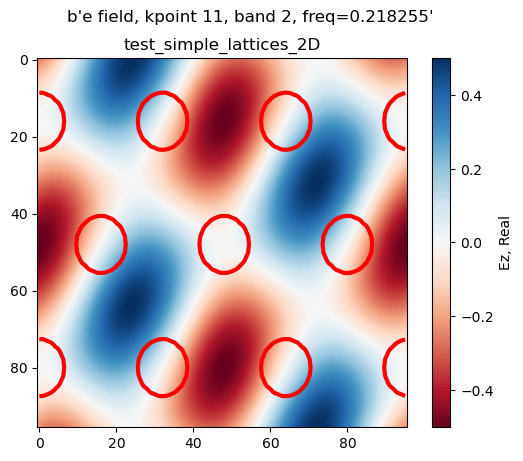

In [7]:
conversion_options = dict(
    periods = 3,
    rectify = True,
    transpose = True
)
viewer.newfig()
viewer.plot_field_data(k_value = 11, b_value = 2, polarization="tm",comp = "z", field_type="e", plot_mode="real", 
                       cmap = "RdBu", conversion_options=conversion_options, overlay_epsilon=True)  


2025-02-25 12:41:29,328 - DEBUG - Running mpb-data conversion command: source /dtu/sw/dcc/dcc-sw.bash && module load mpb/1.11.1 && mpb-data -r -x 3 -y 1 -T -o test_simple_lattices_2D/test_simple_lattices_2D-e.k01.b02.z.tm.converted.h5 test_simple_lattices_2D/test_simple_lattices_2D-e.k01.b02.z.tm.h5


1.0
Log level set to DEBUG


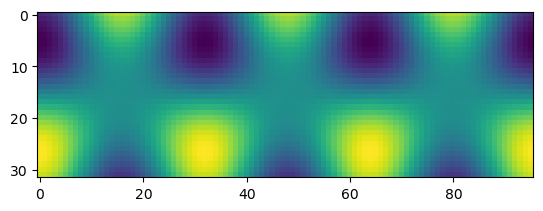

In [8]:
df = sim.load_frequency_data("tm")
row = sim.find_closest_k_point_row(df, (0,0,0))
print(row["k index"])
file_path = sim.find_field_data(1,2,"z", "tm", "e")
data_field = sim.load_h5_data(file_path)
data_field.keys()
data_field["z.r"].shape

conversion_options = dict(
    periods = (3,1),
    rectify = True,
    transpose = True,
    pixellized = False
)

sim.set_verbosity(Simulation.DEBUG)
output_path = sim.convert_field_data(1,2,"z", "tm", "e", conversion_options)
data_converted = sim.load_h5_data(output_path)
data_converted["z.r"].shape
import matplotlib.pyplot as plt
plt.imshow(data_converted["z.r"])


In [9]:
#simulation_slab.run_hpc_lsf(mpb_command_line_params={"r1":0.20, "h":0.4}, num_procs=20)

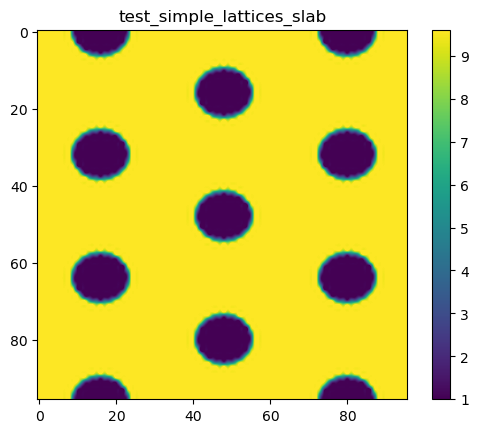

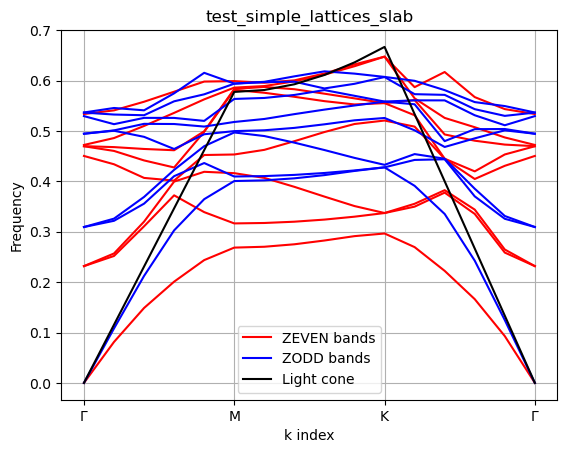

In [10]:
sim = simulation_slab
sim.load_epsilon()
df =sim.load_frequency_data("zodd")

conversion_options = dict(
    periods = (3, 3, 1),
    rectify = True, 
)
viewer = SimulationViewer(sim)
viewer.newfig()
viewer.plot_epsilon_2d(conversion_options=conversion_options)
viewer.show()
viewer.plot_band_diagram("zeven", colors = "red", k_points_path=k_points)
viewer.plot_band_diagram("zodd",  colors = "blue", k_points_path=k_points)
viewer.plot_light_cone(df = df) 

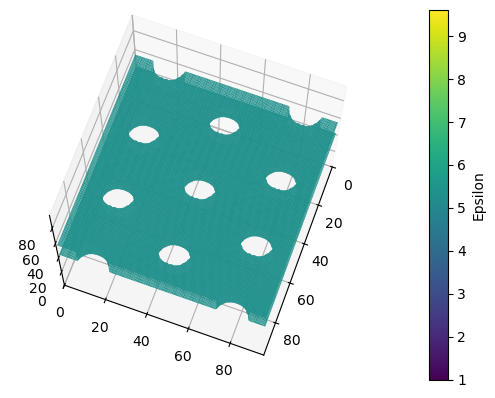

In [11]:
viewer.newfig()
viewer.plot_epsilon_3d(conversion_options=conversion_options, alpha=1)
viewer.rotate_fig(20, 70)  


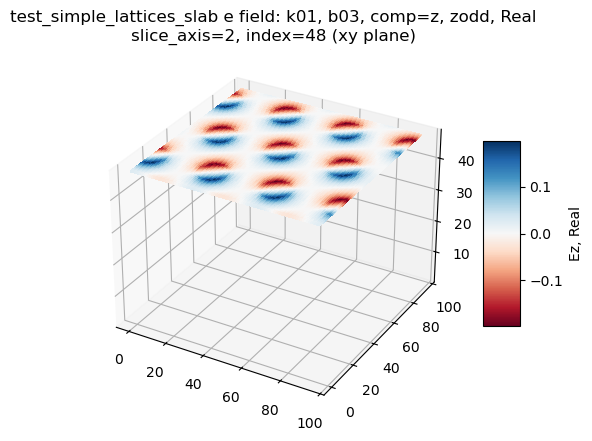

In [30]:

conversion_options = dict(
    periods = (3,3,1),
    rectify = True,
    transpose = False,
    pixellized = False
)
viewer.newfig()
viewer.plot_field_data(k_value = 1, b_value = 3, polarization="zodd",comp = "z", field_type="e", plot_mode="real", 
                       cmap = "RdBu", conversion_options=conversion_options, slice_axis=2,
                       overlay_epsilon_slice_contour=True, overlay_epsilon=False)

